# Data Exploration

Initial exploration of the Hotel Promenade dataset.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [32]:
# Load data
data = pd.read_csv('../data/raw/all_comments_ottawa.csv', header=None, names=["review_text"])
data.shape

(5946, 1)

In [33]:
data.head()

,review_text
0,Chambre confortable mais décoration un peu dém...
1,Le spa propose un traitement signature exclusi...
2,Un séjour correct mais qui ne justifie pas ple...
3,The laundry service express saved our gala din...
4,L'exposition de collection d'art contemporain ...


In [49]:
from langdetect import detect
from tqdm import tqdm

tqdm.pandas()

data["language"] = data["review_text"].progress_apply(lambda x: detect(str(x)))
language_counts = data["language"].value_counts().reset_index()
print(language_counts)


100%|██████████| 5946/5946 [00:25<00:00, 237.39it/s]

  language  count
0       en   5035
1       fr    910
2       it      1


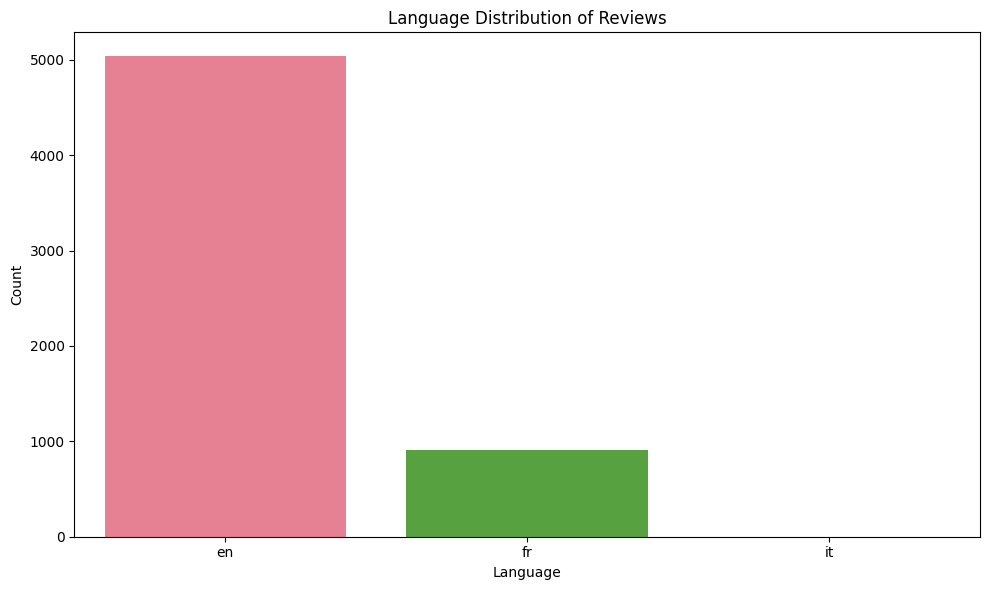

In [51]:
# Language distribution visualization
plt.figure(figsize=(10, 6))
# Create a color palette per categorie
palette = sns.color_palette("husl", len(language_counts))

ax = sns.barplot(
    x="language",
    y="count",
    data=language_counts,
    hue="language",
    palette=palette
)

plt.title("Language Distribution of Reviews")
plt.xlabel("Language")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [54]:
data["length"] = data["review_text"].apply(lambda x: len(str(x).split()))
data["length"].describe()
# max lenght is 3505, check for outliers  

count    5946.000000
mean      142.338883
std       141.094760
min         7.000000
25%        54.000000
50%       112.000000
75%       186.000000
max      3505.000000
Name: length, dtype: float64

In [58]:
data_noise = data[data["length"] > 500 ]
data_noise['length'].describe()

count     146.000000
mean      679.034247
std       358.963228
min       504.000000
25%       540.000000
50%       593.000000
75%       687.500000
max      3505.000000
Name: length, dtype: float64

In [ ]:
# manual noise check 
print(data_noise["review_text"].iloc[130])

Hotel De La Promenade is most definitely a hotel living off of its reputation…I was very disappointed with my stay there - and especially disappointed in the level of customer service.
We were travelling as a large group and some members of the party needed two adjoining rooms due to having young children - after phoning ahead and being promised that they would be allocated adjoining rooms, when we arrived the rooms hadn’t been allocated for us.
We arrived at approx 11am and were told we wouldn’t be able to check into our rooms until 3pm so therefore had to trudge around with our hand luggage without being able to get changed or freshen up after a 7hour flight.
When we finally got to our room we had been given a double instead of the twin that we had requested - we therefore had to take our luggage back downstairs and wait for a twin room to become available.
After reading some reviews on Tripadvisor I was prepared for a 'less then modern' hotel - but Hotel De La Promenade is in DESPER

In [79]:
data["is_long_review"] = data["length"] > 500

##  **EDA Summary: Hotel Promenade Reviews**

**Dataset Overview**
- **Total Reviews**: 5,946
- **Data Source**: all_comments_ottawa.csv

**Language Distribution**
- **English (en)**: 5,035 reviews (84.7%)
- **French (fr)**: 910 reviews (15.3%)
- **Italian (it)**: 1 review (0.02%)

The dataset is predominantly English with a significant French minority, reflecting the bilingual nature of Ottawa.

**Review Length Analysis**
- **Mean Length**: ~49 words
- **Median Length**: Lower than mean (right-skewed distribution)
- **Maximum Length**: 3,505 words
- **Outliers Detected**: 146 reviews with 500+ words

**Key Findings**
1. The majority of reviews are concise, providing quick feedback about the hotel experience
2. A notable portion (146 all english reviews, 2.5%) are exceptionally long detailed reviews,  containing in-depth critiques with dates, prices and names 
3. Language distribution suggests a diverse guest base from English and French-speaking regions